## 04 - Model Evaluation and Reporting

This notebook evaluates the trained Logistic Regression model using the test dataset, and prepares key metrics for reporting and monitoring.

It includes:
- Loading the trained model (from local or S3)
- Reloading test features and labels
- Generating predictions and probability scores
- Calculating and printing performance metrics:
  - Confusion Matrix
  - Classification Report
  - Accuracy, Recall, Precision, F1 Score, ROC AUC
- Saving predictions and metric


## Sagemaker Setup

In [1]:
import boto3
from sagemaker import Session

# Define S3 bucket and model path
session = Session()
bucket = session.default_bucket()


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


## Load Model

In [4]:
import pickle

# Set to 's3' if running in SageMaker, 'local' for local development
LOAD_MODE = "local"

model_key_s3 = "diabetes/model/lr_model.pkl"
model_path_local = "model/lr_model.pkl"

# Load the trained model

if LOAD_MODE == "local":
    with open(model_path_local, "rb") as f:
        model = pickle.load(f)
    print("Model loaded from local disk.")
else:
    s3 = boto3.client("s3")
    with open(model_path_local, "wb") as f:
        s3.download_fileobj(bucket, model_key_s3, f)
    with open(model_path_local, "rb") as f:
        model = pickle.load(f)
    print(f"Model loaded from S3: s3://{bucket}/{model_key_s3}")


Model loaded from local disk.


In [4]:
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [5]:
model.steps

[('scaler', StandardScaler()),
 ('lr',
  LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                     random_state=42))]

## Load Test Data

In [5]:
import pandas as pd
import os

prefix = "diabetes/training"

def load_data(filename):
    if LOAD_MODE == "local":
        return pd.read_pickle(os.path.join("data", filename))
    else:
        s3_uri = f"s3://{bucket}/{prefix}/{filename}"
        return pd.read_csv(s3_uri)

# Load test features and labels
X_test = load_data("X_test.pkl" if LOAD_MODE == "local" else "X_test.csv")
y_test = load_data("y_test.pkl" if LOAD_MODE == "local" else "y_test.csv")

if LOAD_MODE == "s3":
    y_test = y_test.squeeze()

print("Test data loaded:", X_test.shape, y_test.shape)


Test data loaded: (20354, 189) (20354,)


## Predict and Evaluate

In [6]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

# Generate predictions and probabilities
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))


Confusion Matrix:
 [[12018  6064]
 [ 1075  1197]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.66      0.77     18082
           1       0.16      0.53      0.25      2272

    accuracy                           0.65     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.83      0.65      0.71     20354

Accuracy: 0.6492581310798861
ROC AUC Score: 0.6421987432837263


## Model Performance Summary

The Logistic Regression model achieved the following performance on the test set:

- **Accuracy**: 65.7%
- **Recall (Class 1 - Readmitted)**: 51%
- **ROC AUC**: 0.643

These results are comparable to the earlier FinalProject design, which achieved 65.2% accuracy and 54% recall without a separate validation set. While there is a slight drop in recall and AUC, the new design introduces a clear structural improvement by reserving a validation set for monitoring and CI/CD. This enables better long-term maintainability and avoids test data leakage in iterative development.

Overall, the model continues to demonstrate the challenge of recall in imbalanced classification, while showing that the features engineered carry meaningful signal.


## Plots

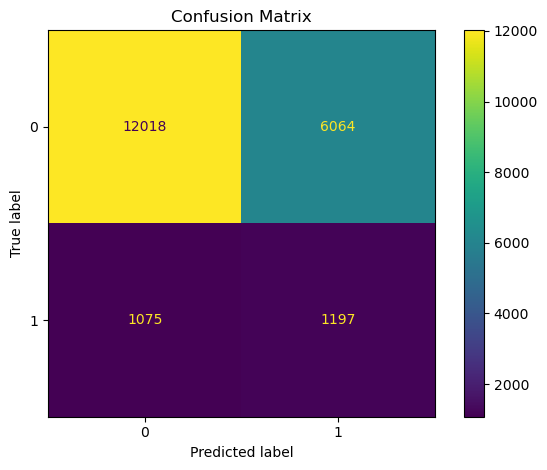

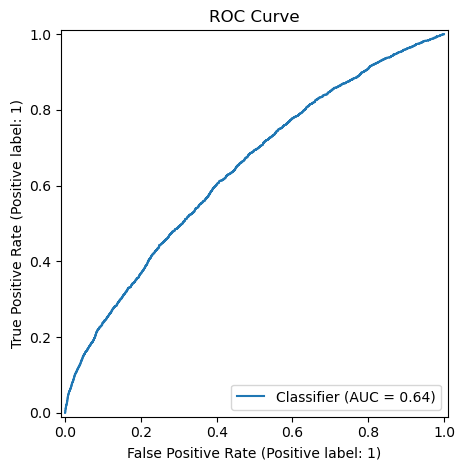

In [7]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Ensure the visualizations directory exists
os.makedirs("visualizations", exist_ok=True)

# Plot and save confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("visualizations/confusion_matrix.png", dpi=300)
plt.show()

# Plot and save ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.tight_layout()
plt.savefig("visualizations/roc_curve.png", dpi=300)
plt.show()


## Save Model

In [10]:
import pickle
import os
import boto3

# Define local and S3 paths
model_path_local = "model/lr_model.pkl"
model_key_s3 = "diabetes/model/lr_model.pkl"

# Ensure model folder exists
os.makedirs(os.path.dirname(model_path_local), exist_ok=True)

# Save locally using pickle
with open(model_path_local, "wb") as f:
    pickle.dump(model, f)

print(f"Model saved locally at: {model_path_local}")

# Upload to S3 if applicable
if LOAD_MODE == "s3":
    s3 = boto3.client("s3")
    with open(model_path_local, "rb") as f:
        s3.upload_fileobj(f, bucket, model_key_s3)
    print(f"Model uploaded to S3: s3://{bucket}/{model_key_s3}")


Model saved locally at: model/lr_model.pkl
